In [458]:
import numpy as np
import matplotlib.pyplot as plt

In [459]:
m=10000
c=5
Dx=600
Da1=128
Da2=64

X=np.random.randn(m,Dx)


In [460]:
#One-hot encoding
y_labels=np.random.randint(0,c,size=m)
y=np.zeros((m,c))
y[np.arange(m),y_labels]=1

In [461]:
W1=np.random.randn(Dx,Da1)
b1=np.zeros((Da1,1))

W2=np.random.randn(Da1,Da2)
b2=np.zeros((Da2,1))

W3=np.random.randn(Da2,c)
b3=np.zeros((c,1))




In [462]:
#Activation Functions

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0,z)

def sigmoid(z):
    return 1/(1+np.exp(-z))

def softmax(z):
    exps=np.exp(z-np.max(z,axis=1,keepdims=True))
    return exps/np.sum(exps,axis=1,keepdims=True)



In [463]:

def ForwardPropagation(W1,W2,W3,b1,b2,b3,X):

    z1=np.dot(X,W1)+b1.T
    a1=relu(z1)

    z2=np.dot(a1,W2)+b2.T
    a2=relu(z2)

    z3=np.dot(a2,W3)+b3.T
    a3=y_hat=softmax(z3)

    return (z1,a1,z2,a2,z3,a3)



# Batch Gradient Descent

In [464]:
def Loss_Func(y_hat,y,epoch,m):
    loss=(-1/m)*np.sum(y*np.log(y_hat+1e-8))

    print(f"The Loss at {epoch} is={loss}")

    return loss

In [465]:
def Backpropagation(W1,W2,W3,b1,b2,b3,z1,z2,z3,a1,a2,y_hat,X,y,lr):

    #1
    dL_dz3=1/m*(y_hat-y)
    dL_dw3=np.dot(a2.T,dL_dz3)
    dL_db3=np.sum(dL_dz3,axis=0,keepdims=True)

    #2
    dL_da2=np.dot(dL_dz3,W3.T)
    dL_dz2=dL_da2*(z2>0)
    dL_dw2=np.dot(a1.T,dL_dz2)
    dL_db2=np.sum(dL_dz2,axis=0,keepdims=True)

    #3
    dL_da1=np.dot(dL_dz2,W2.T)
    dL_dz1=dL_da1*(z1>0)
    dL_dw1=np.dot(X.T,dL_dz1)
    dL_db1=np.sum(dL_dz1,axis=0,keepdims=True)


    W3=W3-(lr*dL_dw3)
    b3=b3-(lr*dL_db3).T

    W2=W2-(lr*dL_dw2)
    b2=b2-(lr*dL_db2).T

    W1=W1-(lr*dL_dw1)
    b1=b1-(lr*dL_db1).T
    
    return (W3,b3,W2,b2,W1,b1)



In [466]:
def Fit(W1, W2, W3, b1, b2, b3, learning_rate, epochs):
    loss_history = [] 
    
    for i in range(epochs):

        (z1, a1, z2, a2, z3, a3) = ForwardPropagation(W1, W2, W3, b1, b2, b3, X)
        
        curr_loss = Loss_Func(a3, y, i, m)
        loss_history.append(curr_loss)
        
        (W3, b3, W2, b2, W1, b1) = Backpropagation(W1, W2, W3, b1, b2, b3, z1, z2, z3, a1, a2, a3, X, y, learning_rate)
        
    return loss_history, W1, W2, W3, b1, b2, b3

The Loss at 0 is=1.6094292043271405
The Loss at 1 is=1.609423873335209
The Loss at 2 is=1.609418745827205
The Loss at 3 is=1.6094138135589227
The Loss at 4 is=1.6094090690841463
The Loss at 5 is=1.6094045054999992
The Loss at 6 is=1.6094001153049522
The Loss at 7 is=1.609395891686067
The Loss at 8 is=1.609391827542045
The Loss at 9 is=1.6093879167512022
The Loss at 10 is=1.609384152884665
The Loss at 11 is=1.6093805304762219
The Loss at 12 is=1.6093770431965049
The Loss at 13 is=1.6093736860213526
The Loss at 14 is=1.6093704535686415
The Loss at 15 is=1.6093673404224489
The Loss at 16 is=1.6093643421669663
The Loss at 17 is=1.6093614545026442
The Loss at 18 is=1.6093586728768448
The Loss at 19 is=1.60935599291774
The Loss at 20 is=1.609353410298199
The Loss at 21 is=1.609350921177098
The Loss at 22 is=1.6093485221479003
The Loss at 23 is=1.6093462094546043
The Loss at 24 is=1.6093439800225853
The Loss at 25 is=1.6093418300951654
The Loss at 26 is=1.6093397566372782
The Loss at 27 is=1.

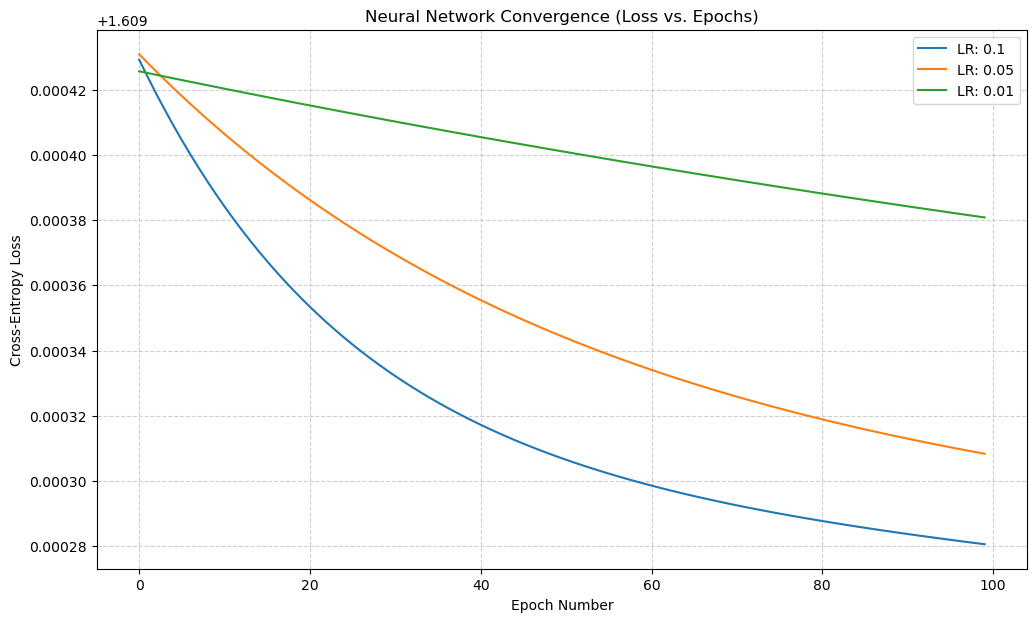

In [ ]:
learning_rates=[0.5,0.01,0.05,0.1,0.5]
epoch_list=[50,100,200,500]

for i in learning_rates:
    for j in epoch_list:
        Fit(W1,W2,W3,b1,b2,b3,i,j)
